In [1]:
import os, psutil, gc
import json, pickle
import time
import pprint
import copy 
import importlib

from collections import defaultdict
import random
import numpy as np

import logging
logging.basicConfig(format='%(message)s', level=logging.ERROR)

import matplotlib.pyplot as plt

from vllm import LLM, SamplingParams, PoolingParams
from sal.config import Config

from utils.load_data import load_data_prm800k_hf
from utils import utils

INFO 11-04 08:14:49 [__init__.py:244] Automatically detected platform cuda.


In [2]:
# base_dir
base_dir = '/groups/kjun/tnn/datasets/'

# dataset path
data_dir = base_dir + "/prm800k/math_splits1"

# llm and prm path
# llm_dir = base_dir + "/Llama-3.2-1B-Instruct-GGUF/Llama-3.2-1B-Instruct.Q4_K_M.gguf"
# prm_dir = base_dir + "/Llama3.1-8B-PRM-Deepseek-Data-GGUF/Llama3.1-8B-PRM-Deepseek-Data.Q4_K_M.gguf"

llm_dir = base_dir + "/Llama-3.2-1B-Instruct"
prm_dir = base_dir + "/Llama3.1-8B-PRM-Deepseek-Data"

In [3]:
# llm_gpu_memory_utilization = 0.5
# llm_vllm_embeds = LLM(
#     model=llm_dir, 
#     tensor_parallel_size=1, 
#     # trust_remote_code=True,
#     task="embed",
#     swap_space=16,
#     max_model_len=6000,
#     gpu_memory_utilization=llm_gpu_memory_utilization,
#     enforce_eager=True,
#     distributed_executor_backend=None,
#     dtype="float16",
#     seed=0,
# )

In [4]:
# config = Config()
# config.agg_strategy = 'last'
# config.date_string = "Aug 1 2025"
# config.normalize_embeds = True

# level = 4 
# num_trials = 5 

# # load data 
# dataset_orig = load_data_prm800k_hf(data_dir, level)

# config_name = f"bon--level-4--v01_0_0--bs-256"
# # config_name = f"mcts--level-4--q-000--q31--n-4--d-20--b-80--cpuct-2"
# result_dir = f"results/bon--level-{level}/{config_name}"
# # print(f"config_name = {config_name}")

# importlib.reload(utils)

# all_embeds = []
# for trial_idx in range(num_trials):
#     print(f"\n-> trial_idx = {trial_idx}")
#     # trial_embeds = utils.extract_completions_embeds(
#     #     result_dir, config_name, trial_idx, dataset_orig, llm_vllm_embeds, config=config)
#     all_embeds += trial_embeds
#     trial_embeds = np.vstack(trial_embeds)
#     print(len(trial_embeds))
#     np.savetxt(f"{result_dir}/embeds_{config_name}--trial-{trial_idx:03d}.npy", trial_embeds)
    

In [5]:
config = Config()
config.agg_strategy = 'last'
config.date_string = "Aug 1 2025"
config.normalize_embeds = True

level = 4 
num_trials = 5 

# load data 
dataset_orig = load_data_prm800k_hf(data_dir, level)

config_name = f"bon--level-4--v01_0_0--bs-256"
# config_name = f"mcts--level-4--q-000--q31--n-4--d-20--b-80--cpuct-2"
result_dir = f"results/bon--level-{level}/{config_name}"
# print(f"config_name = {config_name}")

importlib.reload(utils)

all_embeds = []
for trial_idx in range(num_trials):
    print(f"\n-> trial_idx = {trial_idx}")
    trial_embeds = np.load(f"{result_dir}/embeds_{config_name}--trial-{trial_idx:03d}.npy")
    print(len(trial_embeds))
    all_embeds.append(trial_embeds)

all_embeds = np.vstack(all_embeds)


-> trial_idx = 0
32768

-> trial_idx = 1
32768

-> trial_idx = 2
32768

-> trial_idx = 3
32768

-> trial_idx = 4
32768


In [6]:
all_embeds_mean = np.mean(all_embeds, axis=0, keepdims=True)
all_embeds_mean_centered = all_embeds - all_embeds_mean_centered

(1, 2048)


In [11]:
np.save(f"{result_dir}/embeds_mean_{config_name}.npy", all_embeds_mean)

In [9]:
trial_idx = 0
trial_embeds = np.load(f"{result_dir}/embeds_{config_name}--trial-{trial_idx:03d}.npy")
trial_cosine_sim = trial_embeds @ trial_embeds.T
trial_i_upper = np.triu_indices_from(trial_cosine_sim, k=1)
trial_unique_sims = trial_cosine_sim[trial_i_upper]
# print(trial_unique_sims)

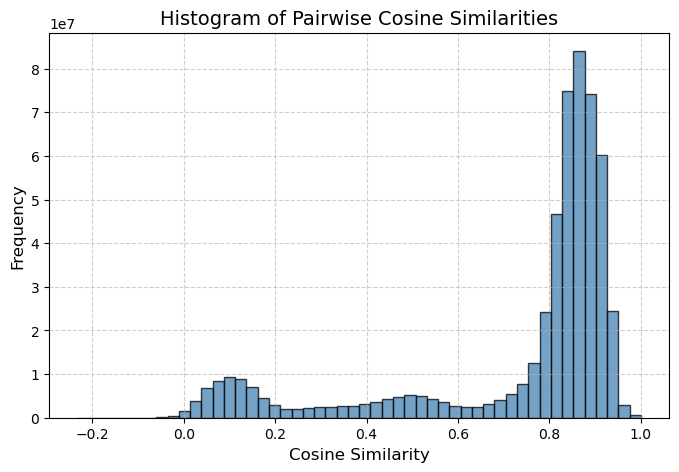

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(trial_unique_sims, bins=50, color='steelblue', alpha=0.75, edgecolor='black')

plt.title('Histogram of Pairwise Cosine Similarities', fontsize=14)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
trial1_idx = 1
trial1_embeds = np.load(f"{result_dir}/embeds_{config_name}--trial-{trial_idx:03d}.npy")

In [ ]:
trial_embeds_mean = np.mean(trial_embeds, axis=0, keepdims=True)
trial_mc_embeds = trial_embeds - trial_embeds_mean
trial_mc_cosine_sim = trial_mc_embeds @ trial_mc_embeds.T
trial_mc_i_upper = np.triu_indices_from(trial_mc_cosine_sim, k=1)
trial_mc_unique_sims = trial_mc_cosine_sim[trial_mc_i_upper]

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(trial_mc_unique_sims, bins=50, color='steelblue', alpha=0.75, edgecolor='black')

plt.title('Histogram of Mean-Centered Pairwise Cosine Similarities', fontsize=14)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
trial1_idx = 1
trial1_embeds = np.load(f"{result_dir}/embeds_{config_name}--trial-{trial_idx:03d}.npy")

trial1_mc_embeds = trial1_embeds - trial_embeds_mean
trial1_mc_cosine_sim = trial1_mc_embeds @ trial1_mc_embeds.T
trial1_mc_i_upper = np.triu_indices_from(trial1_mc_cosine_sim, k=1)
trial1_mc_unique_sims = trial1_mc_cosine_sim[trial1_mc_i_upper]

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(trial1_mc_unique_sims, bins=50, color='steelblue', alpha=0.75, edgecolor='black')

plt.title('Histogram of Mean-Centered Pairwise Cosine Similarities', fontsize=14)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
print(trial1_mc_unique_sims[trial1_mc_unique_sims>1.0])